In [ ]:
#EDA RecSys

Основные таблицы:

- title.basics - основные данные о тайтлах (фильмы, сериалы)

- title.ratings - рейтинги и количество голосов

- title.crew - режиссеры и сценаристы

- title.principals - актеры и съемочная группа

- title.akas - альтернативные названия по странам

- name.basics - информация о людях (актерах, режиссерах)

Перед началом EDA по нужным данным эти таблицы были проанализированы и почищщеы - взяты только фильмы и удалены дефектные значения, дубликаты, после чего получились следующие таблицы:

- title.basics ➡ title.basics.cleaned

- title.ratings ➡ title.ratings.cleaned

- title.crew - ➡ crew.cleaned

- title.principals ➡ principals.cleaned

- title.akas ➡ title.akas.cleaned

- name.basics - осталась такой же. Ее далее будем загружать с сайта imdb. (остальные датасеты загружались аналогичным образом)

# Описание изначальных данных

In [ ]:
!wget -O /content/name.basics.tsv.gz https://datasets.imdbws.com/name.basics.tsv.gz

--2025-11-01 10:19:18--  https://datasets.imdbws.com/name.basics.tsv.gz
Resolving datasets.imdbws.com (datasets.imdbws.com)... 3.167.212.55, 3.167.212.68, 3.167.212.77, ...
Connecting to datasets.imdbws.com (datasets.imdbws.com)|3.167.212.55|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 292836051 (279M) [binary/octet-stream]
Saving to: ‘/content/name.basics.tsv.gz’

/content/name.basic 100%[===================>] 279.27M   256MB/s    in 1.1s    

2025-11-01 10:19:19 (256 MB/s) - ‘/content/name.basics.tsv.gz’ saved [292836051/292836051]



In [ ]:
!gunzip /content/*.gz

Что мы сделали. Взяли ядро - title.basics, содержащее фильмы, отфильтровали все остальные датасеты, связанные с фильмами в соответствие с данным датасетом.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# EDA basics

In [ ]:
t_basics = pd.read_parquet('/content/title_basics_cleaned.parquet')
t_basics.info()
t_basics.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788217 entries, 0 to 788216
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   tconst          788217 non-null  object  
 1   titleType       788217 non-null  category
 2   primaryTitle    788217 non-null  object  
 3   originalTitle   788217 non-null  object  
 4   isAdult         788217 non-null  int8    
 5   startYear       685601 non-null  float32 
 6   runtimeMinutes  788217 non-null  float32 
 7   genres          788217 non-null  object  
dtypes: category(1), float32(2), int8(1), object(4)
memory usage: 31.6+ MB


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100.0,"Documentary,News,Sport"
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,0,1900.0,40.0,"Biography,Drama"
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70.0,"Action,Adventure,Biography"
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90.0,Drama


Что искать:
- Есть ли "провалы" в годах выпуска?
- Какие жанры стабильно популярны?
- Как изменилась средняя продолжительность фильмов?

## Временной анализ

### Распределение фильмов по годам

<Axes: xlabel='startYear', ylabel='Count'>

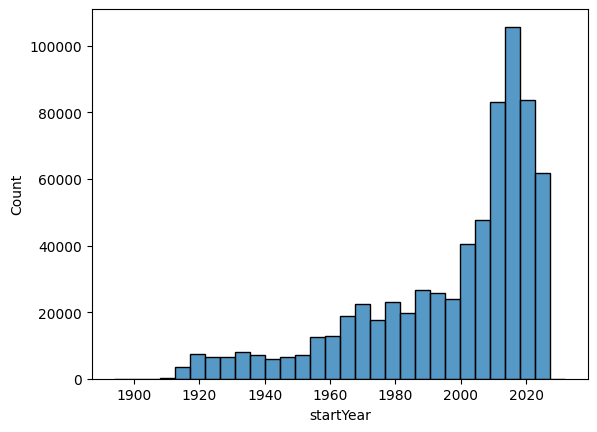

In [ ]:
sns.histplot(data=t_basics, x = 'startYear', bins = 30)

### Эволюция жанров по десятилетиям

In [ ]:
t_basics['genres_list'] = t_basics['genres'].str.split(',')

In [ ]:
# Или проще - сразу из исходных данных:
genre_counts = t_basics['genres_list'].explode().value_counts()
genre_counts.head(20)

,count
genres_list,
Drama,306593
Documentary,191626
Comedy,148772
Action,62940
Romance,58342
Thriller,55753
Crime,48626
Horror,46352
Adventure,33883


In [ ]:
t_basics['decade'] = (t_basics['startYear'] // 10) * 10

In [ ]:
genre_decade = (t_basics.explode('genres_list')
                 .groupby(['decade', 'genres_list'])
                 .size()
                 .reset_index(name = 'count'))
genre_decade

,decade,genres_list,count
0,1890.0,Documentary,17
1,1890.0,News,4
2,1890.0,Romance,1
3,1890.0,Sport,5
4,1900.0,Action,2
...,...,...,...
323,2030.0,Adventure,4
324,2030.0,Animation,2
325,2030.0,Drama,2
326,2030.0,Fantasy,2


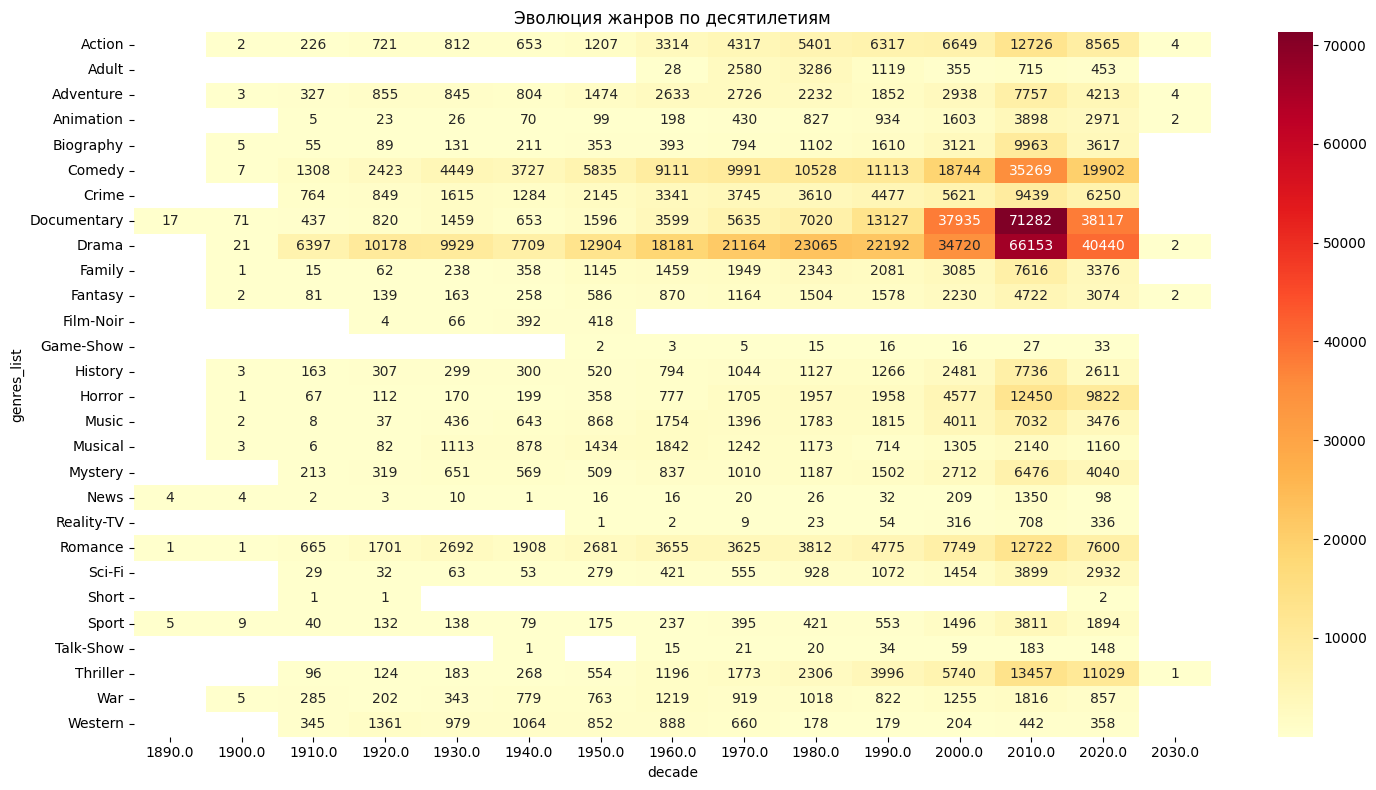

In [ ]:
plt.figure(figsize=(15, 8))
pivot_data = genre_decade.pivot(index='genres_list', columns='decade', values='count')
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Эволюция жанров по десятилетиям')
plt.tight_layout()

<Axes: xlabel='decade', ylabel='count'>

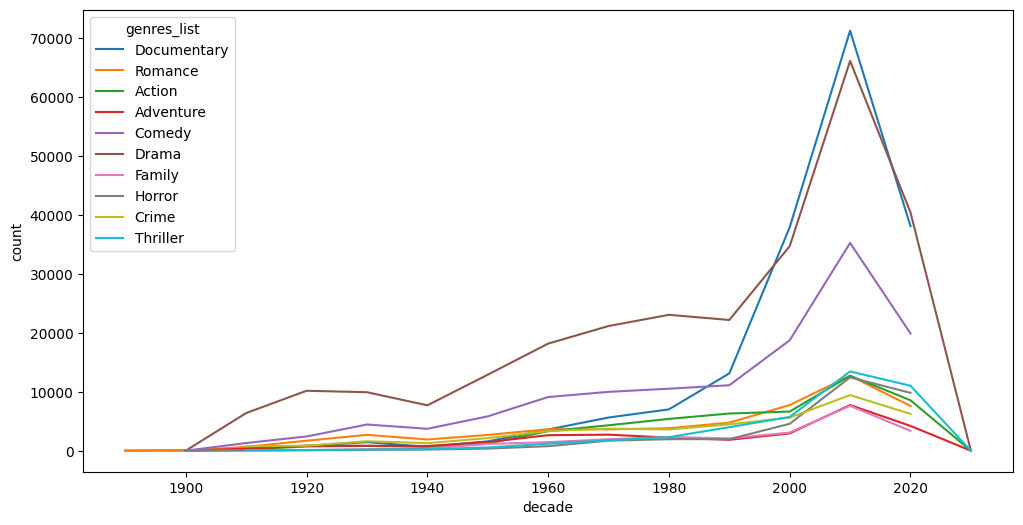

In [ ]:
# Как менялись ТОП 10 Жанров
top_genres = genre_decade.groupby('genres_list')['count'].sum().nlargest(10).index
filtered_data = genre_decade[genre_decade['genres_list'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data, x='decade', y='count', hue='genres_list')

Самые топовые - Doc, Drama, Comedy.
Но посмотрим скрытые тренды

<Axes: xlabel='decade', ylabel='genres_list'>

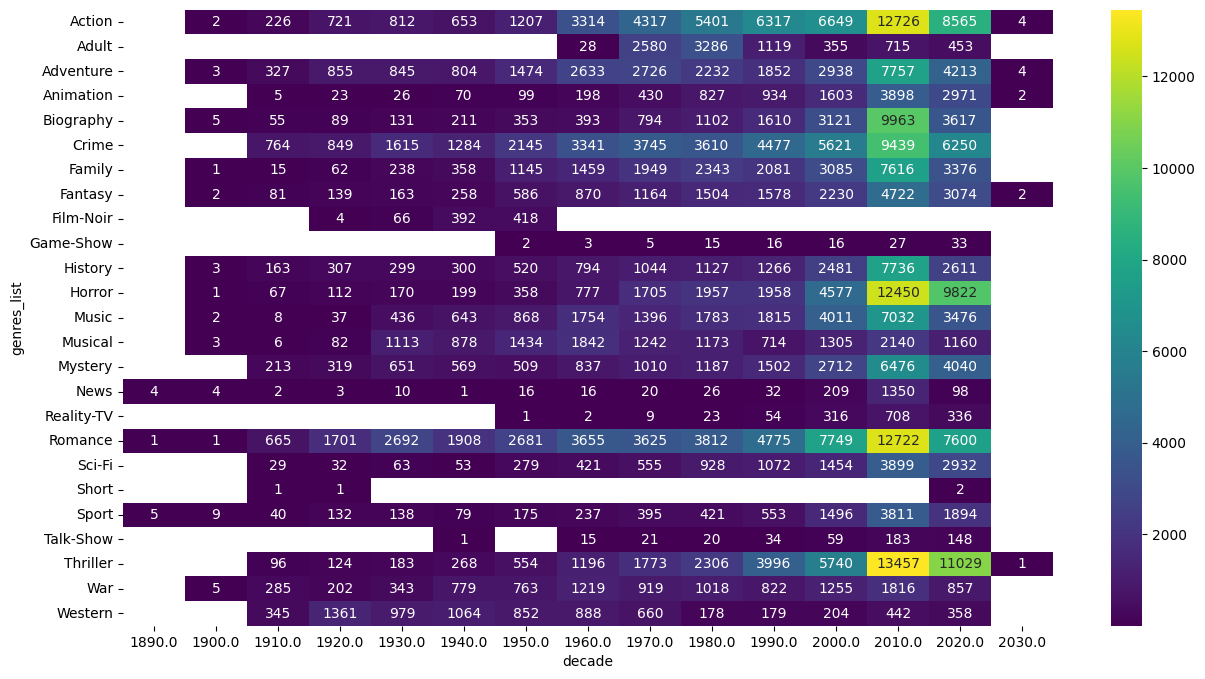

In [ ]:
top3 = ['Drama', 'Comedy', 'Documentary']  # замени на реальные
without_top3 = genre_decade[~genre_decade['genres_list'].isin(top3)]

# Строим heatmap без гигантов
plt.figure(figsize=(15, 8))
pivot_filtered = without_top3.pivot(index='genres_list', columns='decade', values='count')
sns.heatmap(pivot_filtered, cmap='viridis', annot=True, fmt='.0f')

<Axes: xlabel='decade', ylabel='count'>

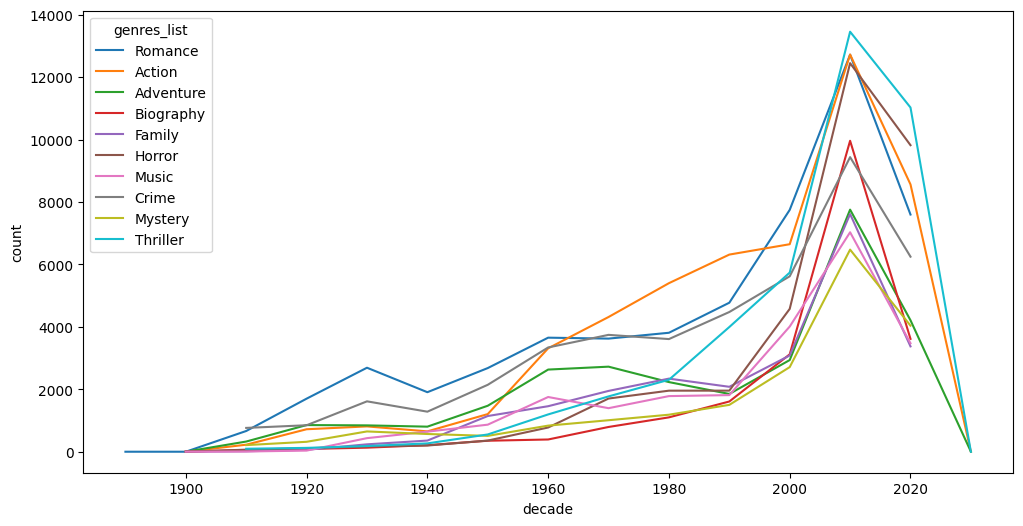

In [ ]:
# Как менялись ТОП 10 Жанров второго эшелона
top_genres = without_top3.groupby('genres_list')['count'].sum().nlargest(10).index
filtered_data = without_top3[without_top3['genres_list'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_data, x='decade', y='count', hue='genres_list')

Инетерсные наблюдения:
- Очень выстрелили триллер и боевик.
Боевик с начала 60-х практически по 2000 возглавлял данный топ
Триллеры всегда были на заднем плане. НО они стали главными фильмами современности
- Также сильный скачок (почти в самый топ пришел биографический жанр)

Идеи:

- Триллер (современность) - новый король
Сигнал: современная аудитория предпочитает напряженные сюжеты.
Делать акцент на триллерах 2000
- Биографический жанр - растущая ниша
- Учитывать возраст пользователя + предпочтения по эпохам

## Углубленный анализ жанров

In [ ]:
# Современные жанры
modern = t_basics[t_basics['startYear'] >= 2000]
modern_genres = modern['genres_list'].explode().value_counts()
display(modern_genres)

,count
genres_list,
Documentary,147334
Drama,141315
Comedy,73915
Thriller,30227
Romance,28071
Action,27944
Horror,26849
Crime,21310
Biography,16701


In [ ]:
# Топ комбинаций жанров
genre_combos = t_basics['genres'].value_counts().head(10)
genre_combos

,count
genres,
Drama,158368
Documentary,151274
Comedy,67352
Horror,20423
Thriller,18714
Action,17208
"Comedy,Drama",16875
"Drama,Romance",15430
Romance,9814


In [ ]:
# Средняя продолжительность по жанрам
genre_duration = t_basics.explode('genres_list').groupby('genres_list')['runtimeMinutes'].mean()
genre_duration

,runtimeMinutes
genres_list,
Action,95.481873
Adult,81.880180
Adventure,89.963165
Animation,77.792801
Biography,84.822632
Comedy,87.823227
Crime,92.119011
Documentary,73.568604
Drama,91.580231


 Порог "настоящего фильма" - 70+ минут

70 мин: Game-Show, News, Talk-Show (не фильмы)


In [ ]:
# Посмотрим пересечение
short_movies = t_basics[
    (t_basics['titleType'] == 'short') |
    (t_basics['genres'].str.contains('Short'))
]

short_movies

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade
4089,tt0010799,movie,Travail,Travail,0,1920.0,143.0,"Drama,Short","[Drama, Short]",1920.0
355554,tt15035322,movie,Eva Constance - Selfish,Eva Constance - Selfish,0,2020.0,89.0,"Music,Short","[Music, Short]",2020.0
364660,tt15406084,movie,Forget Me,Eva Constance-Forget Me,0,2021.0,89.0,"Music,Short","[Music, Short]",2020.0
464083,tt2354498,movie,Et Syndens Barn,Et Syndens Barn,0,1913.0,62.0,"Drama,Short","[Drama, Short]",1910.0


"Short" в жанрах ≠ короткометражка. Это мусорный тег, который портит анализ.

In [ ]:
df_t = t_basics.copy() # сохраним перед удалением тегов

In [ ]:
df_t['genres_list'] = df_t['genres_list'].apply(lambda x: [genre for genre in x if genre != 'Short'])

In [ ]:
# проверим
df_t[df_t['tconst'].isin(['tt0010799', 'tt15035322', 'tt15406084', 'tt2354498'])]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade
4089,tt0010799,movie,Travail,Travail,0,1920.0,143.0,"Drama,Short",[Drama],1920.0
355554,tt15035322,movie,Eva Constance - Selfish,Eva Constance - Selfish,0,2020.0,89.0,"Music,Short",[Music],2020.0
364660,tt15406084,movie,Forget Me,Eva Constance-Forget Me,0,2021.0,89.0,"Music,Short",[Music],2020.0
464083,tt2354498,movie,Et Syndens Barn,Et Syndens Barn,0,1913.0,62.0,"Drama,Short",[Drama],1910.0


In [ ]:
df_t.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100.0,"Documentary,News,Sport","[Documentary, News, Sport]",1890.0
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,0,1900.0,40.0,"Biography,Drama","[Biography, Drama]",1900.0
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70.0,"Action,Adventure,Biography","[Action, Adventure, Biography]",1900.0
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90.0,Drama,[Drama],1900.0


# EDA ratings

In [ ]:
movie_ratings = pd.read_parquet('/content/title_ratings_cleaned.parquet')

## РАСПРЕДЕЛЕНИЕ СРЕДНИХ РЕЙТИНГОВ


1. РАСПРЕДЕЛЕНИЕ СРЕДНИХ РЕЙТИНГОВ:


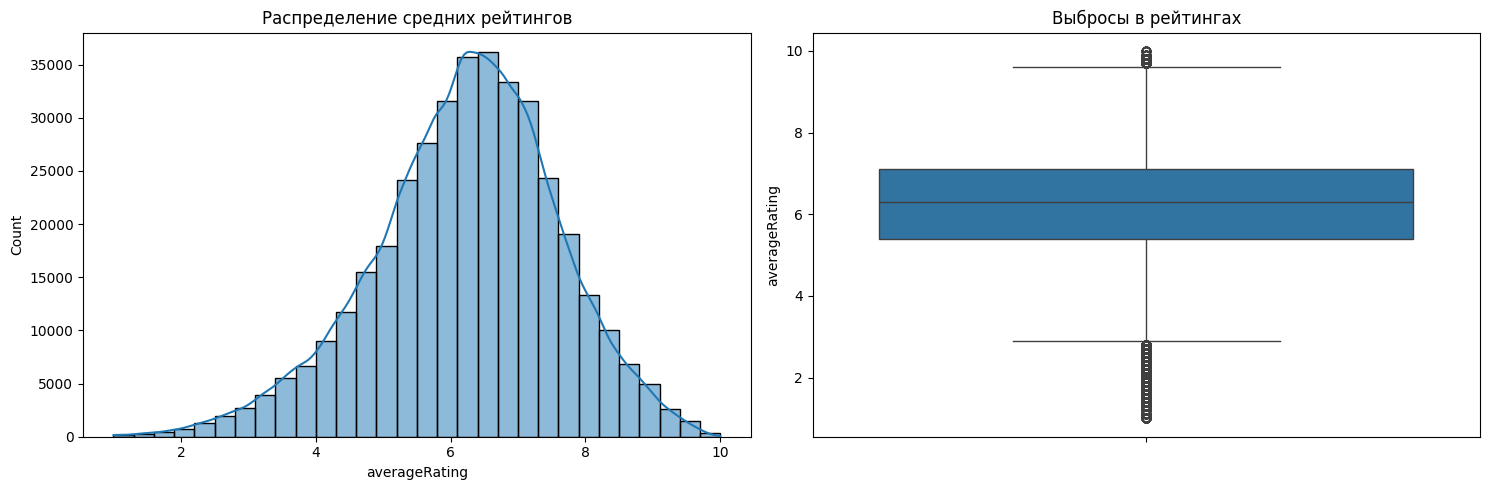

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
sns.histplot(data=movie_ratings, x='averageRating', bins=30, kde = True, ax=ax1)
ax1.set_title('Распределение средних рейтингов')

# Boxplot
sns.boxplot(data=movie_ratings, y='averageRating', ax=ax2)
ax2.set_title('Выбросы в рейтингах')

plt.tight_layout()
plt.show()

## РАСПРЕДЕЛЕНИЕ ГОЛОСОВ


2. РАСПРЕДЕЛЕНИЕ ГОЛОСОВ:


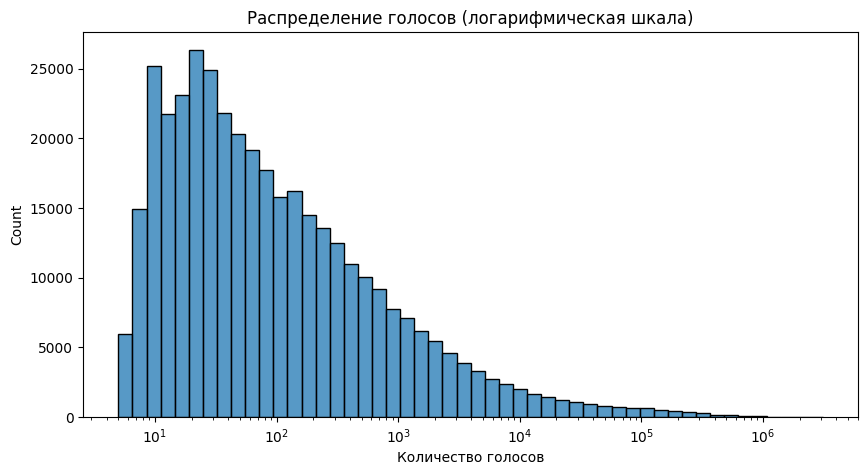

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=movie_ratings, x='numVotes', bins=50, log_scale=True)
plt.title('Распределение голосов (логарифмическая шкала)')
plt.xlabel('Количество голосов')
plt.show()

## Взаимосвязь рейтинга и популярности


3. ВЗАИМОСВЯЗЬ РЕЙТИНГА И ПОПУЛЯРНОСТИ:


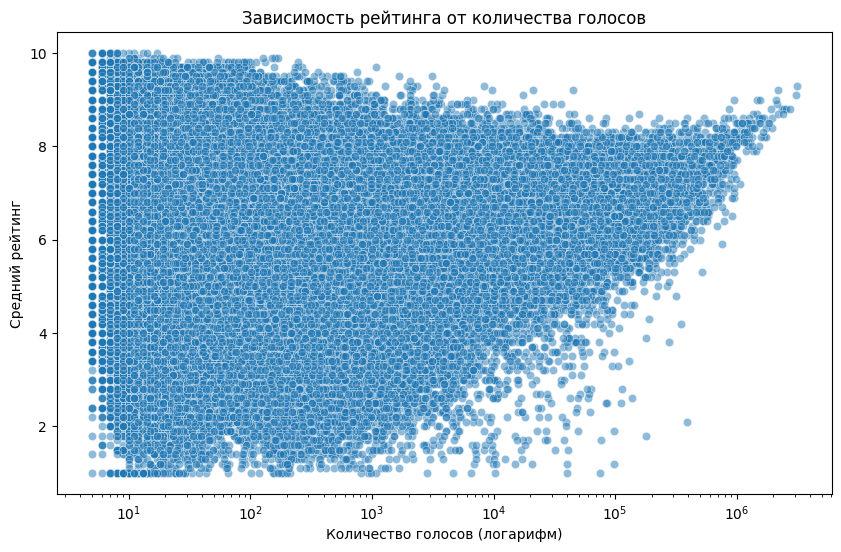

In [ ]:
print("\n3. ВЗАИМОСВЯЗЬ РЕЙТИНГА И ПОПУЛЯРНОСТИ:")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movie_ratings, x='numVotes', y='averageRating', alpha=0.5)
plt.xscale('log')  # обязательно логарифмируем голоса!
plt.title('Зависимость рейтинга от количества голосов')
plt.xlabel('Количество голосов (логарифм)')
plt.ylabel('Средний рейтинг')
plt.show()

# EDA title.basics + title.ratings

In [ ]:
base_in = df_t.merge(movie_ratings, how = 'inner', on ='tconst')
base_left = df_t.merge(movie_ratings, how = 'left', on ='tconst')
print(len(base_in), len(base_left))
print('Теряем:', len(base_left) - len(base_in), ' - мусор')

380674 788217
Теряем: 407543  - мусор


In [ ]:
base_in.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100.0,"Documentary,News,Sport","[Documentary, News, Sport]",1890.0,5.3,574
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,0,1900.0,40.0,"Biography,Drama","[Biography, Drama]",1900.0,5.5,62
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70.0,"Action,Adventure,Biography","[Action, Adventure, Biography]",1900.0,6.0,1033
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90.0,Drama,[Drama],1900.0,5.3,34


## Жанры vs Рейтинг

In [ ]:
# Какие жанры получают самые высокие оценки?
genre_stats = (base_in.explode('genres_list')
               .groupby('genres_list')
               .agg({'averageRating': 'mean', 'numVotes': 'sum'})
               .sort_values('averageRating', ascending=False))
genre_stats

,averageRating,numVotes
genres_list,,
News,7.150070,249683
Documentary,7.144935,18381244
Biography,6.904239,80982172
Music,6.885202,25859218
Game-Show,6.818750,1623
History,6.813406,34753251
Sport,6.647563,20742489
Reality-TV,6.492784,11814
Film-Noir,6.447273,4176744


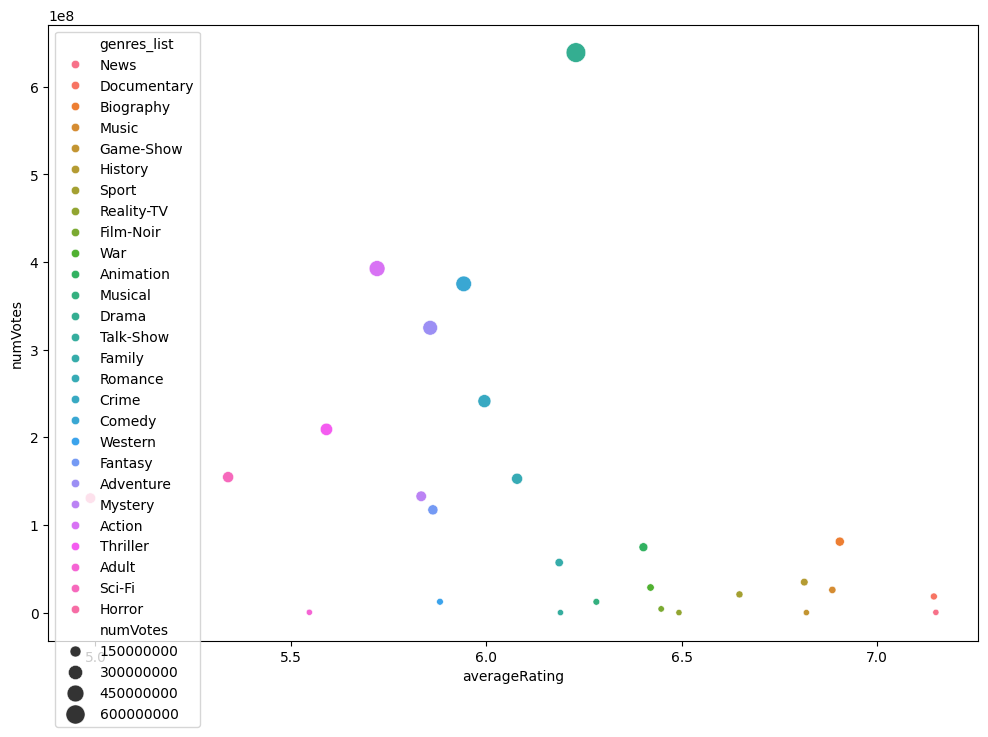

In [ ]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=genre_stats, x='averageRating', y='numVotes',
                         size='numVotes', hue='genres_list', sizes=(20, 200))

In [ ]:
# все нижние можно убрать я думаю..? Убрать можно по какому-то threshhold, который будет прикинут из weighted_raiting

In [ ]:
# Рейтинг, взвешенный по количеству голосов (условно - переменожим, чтобы задействовать оба параметра и поделим на общее количество)
genre_stats['weighted_rating'] = (genre_stats['averageRating'] *
                                 genre_stats['numVotes'] / genre_stats['numVotes'].sum())
genre_stats

,averageRating,numVotes,weighted_rating
genres_list,,,
News,7.150070,249683,0.000551
Documentary,7.144935,18381244,0.040524
Biography,6.904239,80982172,0.172522
Music,6.885202,25859218,0.054938
Game-Show,6.818750,1623,0.000003
History,6.813406,34753251,0.073063
Sport,6.647563,20742489,0.042546
Reality-TV,6.492784,11814,0.000024
Film-Noir,6.447273,4176744,0.008309


In [ ]:
# Лучшие комбинации жанров по рейтингу
genre_combo_ratings = base_in.groupby('genres')['averageRating'].mean().sort_values(ascending=False)
genre_combo_ratings

,averageRating
genres,
"Documentary,Fantasy,Thriller",9.7
"Adult,Reality-TV",9.3
"Documentary,Family,Western",9.1
"Comedy,Drama,Talk-Show",9.0
"Documentary,Reality-TV,Romance",9.0
...,...
"Horror,Mystery,Reality-TV",2.6
"History,Sci-Fi,Thriller",2.5
"Music,Sci-Fi,Thriller",1.5


In [ ]:
# Какой min votes дает стабильные рейтинги?
for threshold in [10, 50, 100, 500]:
    reliable = base_in[base_in['numVotes'] > threshold]
    print(f"Votes > {threshold}: {len(reliable)} films, rating std: {reliable['averageRating'].std():.2f}")

Votes > 10: 342585 films, rating std: 1.35
Votes > 50: 203492 films, rating std: 1.27
Votes > 100: 155665 films, rating std: 1.27
Votes > 500: 73100 films, rating std: 1.22


>100 голосов - стабилизация (std перестает падать)

# EDA title.crew

In [ ]:
df_crew = pd.read_parquet('/content/crew_cleaned.parquet')

In [ ]:
df_crew.head()

,tconst,directors,writers
0,tt0000009,nm0085156,nm0085156
1,tt0000147,nm0714557,None
2,tt0000335,"nm0095714,nm0675140",None
3,tt0000574,nm0846879,nm0846879
4,tt0000591,nm0141150,nm0141150


## Анализ продуктивности

In [ ]:
# Сколько фильмов у топ-режиссеров?
director_counts = df_crew['directors'].str.split(',').explode().value_counts()
print("Топ-10 самых продуктивных режиссеров:")
print(director_counts.head(10))

Топ-10 самых продуктивных режиссеров:
directors
nm0183659     390
nm3248232     218
nm0627864     212
nm0628860     203
nm0064415     193
nm0772905     193
nm0861703     184
nm0001238     182
nm0519117     165
nm12171775    164
Name: count, dtype: int64


In [ ]:
# "Постоянные пары"
director_writer_pairs = df_crew.dropna().apply(lambda x: f"{x['directors']}-{x['writers']}", axis=1)
top_pairs = director_writer_pairs.value_counts().head(10)
top_pairs

,count
nm0183659-nm0183659,277
nm3248232-nm3248232,216
nm0772905-nm0772905,158
nm12171775-nm12171775,137
nm10992938-nm10992938,105
nm7042519-nm7042519,95
nm0879697-nm0879697,88
nm2682776-nm2682776,85
nm1112250-nm1112250,82
nm0781261-nm0781261,79


In [ ]:
# Кто сам пишет сценарии?
self_writers = df_crew[df_crew['directors'] == df_crew['writers']]
len(self_writers)

202175

In [ ]:
# Фильмы с одним vs несколькими режиссерами
df_crew['num_directors'] = df_crew['directors'].str.split(',').str.len()
df_crew['num_writers'] = df_crew['writers'].str.split(',').str.len()

In [ ]:
base_crew = base_in.merge(df_crew, on='tconst', how='inner')

In [ ]:
base_crew.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade,averageRating,numVotes,directors,writers,num_directors,num_writers
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100.0,"Documentary,News,Sport","[Documentary, News, Sport]",1890.0,5.3,574,nm0714557,None,1.0,NaN
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,0,1900.0,40.0,"Biography,Drama","[Biography, Drama]",1900.0,5.5,62,"nm0095714,nm0675140",None,2.0,NaN
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70.0,"Action,Adventure,Biography","[Action, Adventure, Biography]",1900.0,6.0,1033,nm0846879,nm0846879,1.0,1.0
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90.0,Drama,[Drama],1900.0,5.3,34,nm0141150,nm0141150,1.0,1.0


In [ ]:
base_crew.isnull().sum()

,0
tconst,0
titleType,0
primaryTitle,0
originalTitle,0
isAdult,0
startYear,40
runtimeMinutes,0
genres,0
genres_list,0
decade,40


## Хитмейкеры

In [ ]:
base_crew['directors_list'] = base_crew['directors'].str.split(',')

# Фильтруем и по голосам, и по количеству фильмов
director_stats = (base_crew.explode('directors_list')
                 .groupby('directors_list')
                 .agg({'averageRating': 'mean', 'numVotes': 'sum', 'tconst': 'count'})
                 .rename(columns={'tconst': 'film_count'}))


# Только режиссеры с 3+ фильмами и 1000+ голосов суммарно
reliable_directors = director_stats[
    (director_stats['film_count'] >= 3) &
    (director_stats['numVotes'] >= 1000)
]


In [ ]:
reliable_directors.sort_values(by = 'averageRating', ascending = False)

,averageRating,numVotes,film_count
directors_list,,,
nm1411667,9.000000,1242,8
nm0482541,8.966667,1826,3
nm13498791,8.960000,1077,15
nm2119365,8.800000,1134,4
nm4711112,8.766667,17425,3
...,...,...,...
nm4347209,1.966667,1049,3
nm6594610,1.833333,1452,12
nm0290118,1.800000,22297,3


In [ ]:
# Посмотрим распределение
print(base_crew['num_directors'].value_counts().head(10))

num_directors
1.0     337975
2.0      30194
3.0       3325
4.0        899
5.0        501
6.0        283
7.0        199
8.0        138
10.0       109
9.0        101
Name: count, dtype: int64


In [ ]:
base_crew['num_directors'] = base_crew['num_directors'].clip(1, 3) #усекаем незначимые значения

<Axes: xlabel='num_directors', ylabel='averageRating'>

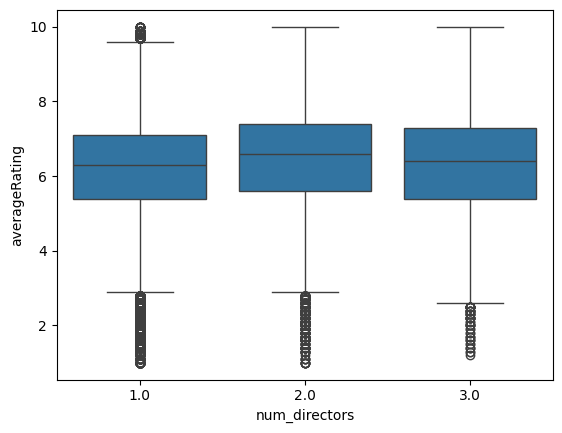

In [ ]:
# Влияет ли число режиссеров на качество?
sns.boxplot(data=base_crew, x='num_directors', y='averageRating')

In [ ]:
# Лучше ли, когда режиссер сам пишет сценарий?
self_writer_rating = base_crew[base_crew['directors'] == base_crew['writers']]['averageRating'].mean()
separate_rating = base_crew[base_crew['directors'] != base_crew['writers']]['averageRating'].mean()
print(self_writer_rating)
print(separate_rating)

6.251475041826384
6.190077418633575


<Axes: xlabel='num_writers', ylabel='averageRating'>

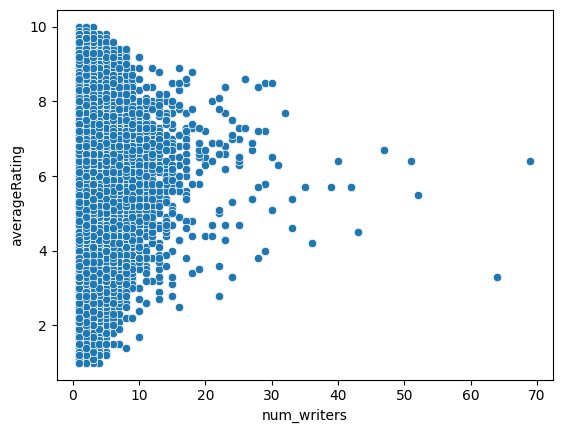

In [ ]:
# Большие команды сценаристов = лучше/хуже?
sns.scatterplot(data=base_crew, x='num_writers', y='averageRating')

In [ ]:
# Усекаем выбросы
base_crew['num_writers'] = base_crew['num_writers'].clip(1, 15)

In [ ]:
base_crew.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade,averageRating,numVotes,directors,writers,num_directors,num_writers,directors_list
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0,[nm0085156]
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,100.0,"Documentary,News,Sport","[Documentary, News, Sport]",1890.0,5.3,574,nm0714557,None,1.0,NaN,[nm0714557]
2,tt0000335,movie,Soldiers of the Cross,Soldiers of the Cross,0,1900.0,40.0,"Biography,Drama","[Biography, Drama]",1900.0,5.5,62,"nm0095714,nm0675140",None,2.0,NaN,"[nm0095714, nm0675140]"
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,70.0,"Action,Adventure,Biography","[Action, Adventure, Biography]",1900.0,6.0,1033,nm0846879,nm0846879,1.0,1.0,[nm0846879]
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,90.0,Drama,[Drama],1900.0,5.3,34,nm0141150,nm0141150,1.0,1.0,[nm0141150]


# EDA title.principals

In [ ]:
principals = pd.read_parquet('/content/principals_cleaned.parquet')

In [ ]:
principals.head()

,tconst,ordering,nconst,category
0,tt0000009,1,nm0063086,actress
1,tt0000009,2,nm0183823,actor
2,tt0000009,3,nm1309758,actor
3,tt0000009,4,nm0085156,director
4,tt0000009,5,nm0085156,writer


In [ ]:
base_principals = base_crew.merge(principals, how = 'inner', on ='tconst')

In [ ]:
base_principals = base_principals.drop('titleType', axis = 1)
base_principals.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,genres_list,decade,averageRating,numVotes,directors,writers,num_directors,num_writers,directors_list,ordering,nconst,category
0,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0,[nm0085156],1,nm0063086,actress
1,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0,[nm0085156],2,nm0183823,actor
2,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0,[nm0085156],3,nm1309758,actor
3,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0,[nm0085156],4,nm0085156,director
4,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,[Romance],1890.0,5.3,230,nm0085156,nm0085156,1.0,1.0,[nm0085156],5,nm0085156,writer


In [ ]:
base_principals.isna().sum()

,0
tconst,0
primaryTitle,0
originalTitle,0
isAdult,0
startYear,519
runtimeMinutes,0
genres,0
genres_list,0
decade,519
averageRating,0


In [ ]:
# Удаляем дублирующиеся колонки из principals
cols_to_drop = ['directors', 'writers', 'num_directors', 'num_writers', 'directors_list', 'genres_list']
base_principals_clean = base_principals.drop(columns=cols_to_drop, errors = 'ignore')

Смотрю на данные: Вижу, что есть directors (строка с ID через запятую) и nconst+category (разложено по строкам)

Логически понимаю: nconst+category содержит ту же информацию, но более детализированную

Принимаю решение: Удаляю агрегированные колонки directors/writers, оставляю детализированные nconst+category


In [ ]:
base_principals_clean.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,decade,averageRating,numVotes,ordering,nconst,category
0,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,1,nm0063086,actress
1,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,2,nm0183823,actor
2,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,3,nm1309758,actor
3,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,4,nm0085156,director
4,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,5,nm0085156,writer


In [ ]:
base_principals_clean.to_parquet('/content/base_principals.parquet', index=False)

# Загружаем name.basics

In [ ]:
names = pd.read_csv('/content/name.basics.tsv', sep ='\t', na_values=['\\N'])
names.head()

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899.0,1987.0,"actor,miscellaneous,producer","tt0072308,tt0050419,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924.0,2014.0,"actress,soundtrack,archive_footage","tt0037382,tt0075213,tt0038355,tt0117057"
2,nm0000003,Brigitte Bardot,1934.0,NaN,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949.0,1982.0,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918.0,2007.0,"writer,director,actor","tt0050986,tt0069467,tt0083922,tt0050976"


In [ ]:
base = pd.read_parquet('/content/base_principals.parquet')
base.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,decade,averageRating,numVotes,ordering,nconst,category
0,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,1,nm0063086,actress
1,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,2,nm0183823,actor
2,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,3,nm1309758,actor
3,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,4,nm0085156,director
4,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,5,nm0085156,writer


In [ ]:
base_merge = base.merge(names, how = 'inner', on = 'nconst')

In [ ]:
base_merge.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,decade,averageRating,numVotes,ordering,nconst,category,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,1,nm0063086,actress,Blanche Bayliss,1878.0,1951.0,actress,tt0000009
1,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,2,nm0183823,actor,William Courtenay,1875.0,1933.0,actor,"tt0000009,tt0020355,tt0021535,tt0020403"
2,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,3,nm1309758,actor,Chauncey Depew,1834.0,1928.0,"actor,writer","tt0000009,tt0490842,tt1076833,tt4484306"
3,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,4,nm0085156,director,Alexander Black,1859.0,1940.0,"director,writer,cinematographer",tt0000009
4,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,5,nm0085156,writer,Alexander Black,1859.0,1940.0,"director,writer,cinematographer",tt0000009


In [ ]:
base_merge.isna().sum()

,0
tconst,0
primaryTitle,0
originalTitle,0
isAdult,0
startYear,519
runtimeMinutes,0
genres,0
decade,519
averageRating,0
numVotes,0


In [ ]:
# Проверим соответствие
print("Category vs primaryProfession:")
for cat in base_merge['category'].unique():
    professions = base_merge[base_merge['category'] == cat]['primaryProfession'].dropna()
    if len(professions) > 0:
        sample_professions = professions.iloc[0]
        print(f"{cat}: {sample_professions}")

# Если category всегда входит в primaryProfession - можно заполнить!

Category vs primaryProfession:
actress: actress
actor: actor
director: director,writer,cinematographer
writer: director,writer,cinematographer
producer: director,writer,cinematographer
cinematographer: director,writer,cinematographer
self: actor,writer,archive_footage
composer: composer,soundtrack
production_designer: actor,production_designer,director
editor: director,cinematographer,writer
archive_footage: archive_footage
casting_director: casting_director
archive_sound: actor,soundtrack,archive_footage


category = конкретная роль ("актер в этом фильме")

primaryProfession = общие профессии ("актер, режиссер, сценарист")

Для RecSys важна роль в конкретном фильме (category)

primaryProfession не добавляет полезной информации

19% пропусков - много

In [ ]:
# Удаляем колонки с высокими пропусками
cols_to_drop = ['birthYear', 'deathYear', 'primaryProfession']
base_final = base_merge.drop(columns=cols_to_drop)
base_final.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,decade,averageRating,numVotes,ordering,nconst,category,primaryName,knownForTitles
0,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,1,nm0063086,actress,Blanche Bayliss,tt0000009
1,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,2,nm0183823,actor,William Courtenay,"tt0000009,tt0020355,tt0021535,tt0020403"
2,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,3,nm1309758,actor,Chauncey Depew,"tt0000009,tt0490842,tt1076833,tt4484306"
3,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,4,nm0085156,director,Alexander Black,tt0000009
4,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,5,nm0085156,writer,Alexander Black,tt0000009


## Анализ строк с пустыми knownForTitles

In [ ]:
missing_knownfor = base_final[base_final['knownForTitles'].isnull()]

print(f"Всего строк: {len(missing_knownfor):,}")

# Смотрим распределение по категориям
print("\nРаспределение по категориям:")
print(missing_knownfor['category'].value_counts())

# Смотрим рейтинги
print("\nСтатистика рейтингов:")
print(missing_knownfor['averageRating'].describe())

# Смотрим популярность (numVotes)
print("\nСтатистика популярности:")
print(missing_knownfor['numVotes'].describe())

=== АНАЛИЗ СТРОК С ПУСТЫМИ knownForTitles ===
Всего строк: 6,420

Распределение по категориям:
category
archive_footage        3215
actor                  1301
self                    682
actress                 646
producer                129
writer                  109
director                 79
composer                 71
cinematographer          68
editor                   56
archive_sound            43
production_designer      11
casting_director         10
Name: count, dtype: int64

Статистика рейтингов:
count    6420.000000
mean        6.792368
std         1.302059
min         1.000000
25%         6.100000
50%         7.000000
75%         7.600000
max         9.900000
Name: averageRating, dtype: float64

Статистика популярности:
count      6420.000000
mean       1453.041589
std       10533.727872
min           5.000000
25%          17.000000
50%          49.000000
75%         240.000000
max      234601.000000
Name: numVotes, dtype: float64


In [ ]:
missing_knownfor.sample(10)

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,decade,averageRating,numVotes,ordering,nconst,category,primaryName,knownForTitles
5195730,tt4599622,Churchill's First World War,Churchill's First World War,0,2013.0,90.0,Drama,2010.0,7.2,98,2,nm0161422,archive_footage,Clementine Churchill,NaN
4225350,tt22682846,Hidden Blessings,Hidden Blessings,0,2024.0,107.0,Drama,2020.0,8.6,33,8,nm14782543,archive_footage,Dalton Marks,NaN
1960210,tt0275981,Bride's Delight,Bride's Delight,1,1971.0,52.0,"Adult,Comedy",1970.0,4.7,18,9,nm7313996,actress,Star,NaN
101728,tt0024770,The White Sister,The White Sister,0,1933.0,105.0,"Drama,Romance",1930.0,6.1,508,9,nm0102798,actress,Mary Bracken,NaN
3108300,tt1196772,Little Rascals Varieties,Little Rascals Varieties,0,1959.0,63.0,"Comedy,Family,Musical",1950.0,7.4,54,10,nm0105922,archive_footage,Tom Braunger,NaN
754027,tt0077961,Die munteren Sexspiele der Nachbarn,Die munteren Sexspiele der Nachbarn,0,1978.0,75.0,Comedy,1970.0,4.7,69,10,nm1549477,actor,Helge Hahnenfeld,NaN
1492459,tt0170062,Irish and Proud of It,Irish and Proud of It,0,1938.0,78.0,"Comedy,Romance",1930.0,3.8,38,9,nm0192893,actor,Wolf Curran,NaN
3992366,tt1980031,A Welcome to Britain,A Welcome to Britain,0,1943.0,60.0,Documentary,1940.0,7.0,110,6,nm8153855,self,John C.H. Lee,NaN
3085344,tt11822898,Stalin and the Katyn Massacre,"Les bourreaux de Staline - Katyn, 1940",0,2020.0,97.0,"Documentary,History",2020.0,8.0,127,2,nm13221128,archive_footage,Wassili Michailowitsch Blochin,NaN
4971759,tt36413902,Peacemaker,Mirotvorac,0,2025.0,99.0,Documentary,2020.0,8.4,136,2,nm17202027,archive_footage,Slobodan Budak,NaN


50% - archive_footage (архивные кадры) - не люди актеры/режиссеры

32% - актеры/актрисы но в основном неизвестные

Рейтинги нормальные (mean=6.8), но популярность низкая (median=49 голосов)

Можно удалить эти данные и в целом их потеря не должна сильно повлиять на рексистему

In [ ]:
base_final_clean = base_final.dropna(subset=['knownForTitles'])
base_final_clean.isna().sum()

,0
tconst,0
primaryTitle,0
originalTitle,0
isAdult,0
startYear,517
runtimeMinutes,0
genres,0
decade,517
averageRating,0
numVotes,0


## Анализ пропущенных годов

In [ ]:
missing_years = base_final_clean[base_final_clean['startYear'].isnull()]

print("=== АНАЛИЗ ПРОПУЩЕННЫХ ГОДОВ ===")
print(f"Строк с пропущенными годами: {len(missing_years)}")

# Смотрим какие люди и фильмы
print("\nЛюди в пропущенных годах:")
print(missing_years['primaryName'].value_counts().head(10))

print("\nФильмы в пропущенных годах:")
print(missing_years['primaryTitle'].value_counts().head(10))

=== АНАЛИЗ ПРОПУЩЕННЫХ ГОДОВ ===
Строк с пропущенными годами: 517

Люди в пропущенных годах:
primaryName
Rubén Arnaiz           6
Freejack               5
Luca Zambianchi        5
Deeshak Patra          5
Dean Allan Tolhurst    5
Ashei Khan             4
Elke Blasi             4
Herbert G. Ponting     4
J.D. Hodge             4
Emily Ann Cecil        3
Name: count, dtype: int64

Фильмы в пропущенных годах:
primaryTitle
Private Dicks                      22
Prem Prakaran                      22
Bay Lawz: Stick to the Code        21
Growing Up with Mi Familia         20
El Arribo de Conrado Sierra        20
Watchdog                           19
*69                                18
N.I.M.: Artificial Intelligence    18
Hell Phone                         17
Lucky Fish                         16
Name: count, dtype: int64


Судя по названиям - это вряд ли блокбастеры

In [ ]:
base_final_clean = base_final_clean.dropna(subset=['startYear'])

In [ ]:
base_final_clean.to_parquet('/content/base_final_clean.parquet', index=False)

# EDA base + AKAS

In [2]:
akas = pd.read_parquet('/content/title_akas_cleaned.parquet')

In [3]:
data_base = pd.read_parquet('/content/base_final_clean.parquet')

In [4]:
akas.head()

,titleId,title,region,language,types,isOriginalTitle
0,tt0000009,Miss Jerry,None,None,original,1
1,tt0000009,Miss Jerry,AU,None,imdbDisplay,0
2,tt0000009,Miss Jerry,HU,None,imdbDisplay,0
3,tt0000009,Miss Jerry,US,None,imdbDisplay,0
4,tt0000009,Fräulein Jerry,DE,None,None,0


In [10]:
akas.isna().sum()

,0
titleId,0
title,1
region,828419
language,3110152
types,673095
isOriginalTitle,0


In [11]:
len(akas)

3830055

In [12]:
# Посмотреть частоту типов названий
akas['types'].value_counts()

,count
types,
imdbDisplay,2180025
original,786059
alternative,77050
working,42251
video,20610
dvd,17724
tv,16637
festival,16224
imdbDisplaydvd,184


In [13]:
important_types = ['imdbDisplay', 'original']
akas_clean = akas[akas['types'].isin(important_types)]

In [ ]:
akas_clean.isna().sum()

In [15]:
akas_agg = akas_clean.groupby('titleId').agg(
    num_translations=('title', 'count'), # сколько у фильма версий названий
    has_original_title=('types', lambda x: 1 if 'original' in x.values else 0),
    main_region=('region', lambda x: x.dropna().mode()[0] if not x.dropna().empty else None),
    is_multiregional=('region', lambda x: 1 if x.nunique() > 1 else 0)
).reset_index()

In [17]:
akas_agg['has_original_title'].value_counts() # бесполезный признак =) но на всякий случай проверили)

,count
has_original_title,
1,786059


In [19]:
df_akas = akas_agg.drop('has_original_title', axis = 1)

In [20]:
df_akas

,titleId,num_translations,main_region,is_multiregional
0,tt0000009,5,AU,1
1,tt0000147,4,EE,1
2,tt0000335,4,AU,1
3,tt0000574,8,AU,1
4,tt0000591,3,FR,1
...,...,...,...,...
786054,tt9916680,2,CO,0
786055,tt9916692,2,PL,0
786056,tt9916706,2,IN,0
786057,tt9916730,2,IN,0


язык убрали, так как там много пропусков, и он обычно просто соответствует региону

In [24]:
data_base.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,decade,averageRating,numVotes,ordering,nconst,category,primaryName,knownForTitles
0,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,1,nm0063086,actress,Blanche Bayliss,tt0000009
1,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,2,nm0183823,actor,William Courtenay,"tt0000009,tt0020355,tt0021535,tt0020403"
2,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,3,nm1309758,actor,Chauncey Depew,"tt0000009,tt0490842,tt1076833,tt4484306"
3,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,4,nm0085156,director,Alexander Black,tt0000009
4,tt0000009,Miss Jerry,Miss Jerry,0,1894.0,45.0,Romance,1890.0,5.3,230,5,nm0085156,writer,Alexander Black,tt0000009


In [25]:
movies_final = data_base[['tconst', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres', 'decade', 'averageRating', 'numVotes']].drop_duplicates()

Сохраним данную таблицу, для возможного дальнейшего использования и создания фич.

In [54]:
movies_final.to_parquet('/content/separation_movies.parquet')

In [27]:
movies_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 380018 entries, 0 to 5987689
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          380018 non-null  object 
 1   primaryTitle    380018 non-null  object 
 2   startYear       380018 non-null  float32
 3   runtimeMinutes  380018 non-null  float32
 4   genres          380018 non-null  object 
 5   decade          380018 non-null  float32
 6   averageRating   380018 non-null  float64
 7   numVotes        380018 non-null  int64  
dtypes: float32(3), float64(1), int64(1), object(3)
memory usage: 21.7+ MB


In [29]:
movies_final.head()

,tconst,primaryTitle,startYear,runtimeMinutes,genres,decade,averageRating,numVotes
0,tt0000009,Miss Jerry,1894.0,45.0,Romance,1890.0,5.3,230
7,tt0000147,The Corbett-Fitzsimmons Fight,1897.0,100.0,"Documentary,News,Sport",1890.0,5.3,574
15,tt0000335,Soldiers of the Cross,1900.0,40.0,"Biography,Drama",1900.0,5.5,62
23,tt0000574,The Story of the Kelly Gang,1906.0,70.0,"Action,Adventure,Biography",1900.0,6.0,1033
43,tt0000591,The Prodigal Son,1907.0,90.0,Drama,1900.0,5.3,34


In [30]:
movies_final.isna().sum()

,0
tconst,0
primaryTitle,0
startYear,0
runtimeMinutes,0
genres,0
decade,0
averageRating,0
numVotes,0


In [32]:
crew_final = data_base[['tconst', 'nconst', 'ordering', 'category', 'primaryName', 'knownForTitles']]

Сохраним данную таблицу, для возможного дальнейшего использования и создания фич.

In [53]:
crew_final.to_parquet('/content/separation_crew.parquet')

In [34]:
crew_final.head(10)

,tconst,nconst,ordering,category,primaryName,knownForTitles
0,tt0000009,nm0063086,1,actress,Blanche Bayliss,tt0000009
1,tt0000009,nm0183823,2,actor,William Courtenay,"tt0000009,tt0020355,tt0021535,tt0020403"
2,tt0000009,nm1309758,3,actor,Chauncey Depew,"tt0000009,tt0490842,tt1076833,tt4484306"
3,tt0000009,nm0085156,4,director,Alexander Black,tt0000009
4,tt0000009,nm0085156,5,writer,Alexander Black,tt0000009
5,tt0000009,nm0085156,6,producer,Alexander Black,tt0000009
6,tt0000009,nm0085156,7,cinematographer,Alexander Black,tt0000009
7,tt0000147,nm0179163,1,self,James J. Corbett,"tt0003116,tt0003730,tt0034778,tt0020949"
8,tt0000147,nm0280615,2,self,Bob Fitzsimmons,"tt0232530,tt0000147,tt0230692,tt4655120"
9,tt0000147,nm4082222,3,self,Billy Madden,tt0000147


In [36]:
crew_final.isna().sum()

,0
tconst,0
nconst,0
ordering,0
category,0
primaryName,0
knownForTitles,0


In [37]:
crew_final['category'].value_counts()

,count
category,
actor,1871679
actress,1043837
writer,590364
producer,489789
director,409198
cinematographer,370868
editor,368442
composer,312068
self,255641


In [38]:
# Длина knownForTitles как метрика известности
crew_final['star_power'] = crew_final['knownForTitles'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
crew_final['star_power'].describe()

/tmp/ipython-input-1113848240.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crew_final['star_power'] = crew_final['knownForTitles'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)


,star_power
count,5.987703e+06
mean,3.650718e+00
std,8.852836e-01
min,1.000000e+00
25%,4.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,4.000000e+00


In [39]:
# На каком порядке обычно идут главные актеры?
crew_final[crew_final['category'] == 'actor']['ordering'].value_counts().sort_index()

,count
ordering,
1,209900
2,180045
3,189420
4,188878
5,189041
6,185230
7,181751
8,176746
9,170485


Этот EDA покажет:

Как измерять "вес" актера в фильме

Какие категории команды самые влиятельные

Как использовать ordering и knownForTitles для фичей

In [41]:
movies_with_akas = movies_final.merge(akas_agg, left_on='tconst', right_on='titleId', how='left')

In [43]:
movies_with_akas.isna().sum()

,0
tconst,0
primaryTitle,0
startYear,0
runtimeMinutes,0
genres,0
decade,0
averageRating,0
numVotes,0
titleId,508
num_translations,508


In [45]:
# Заполняем пропуски
movies_with_akas['num_translations'] = movies_with_akas['num_translations'].fillna(0)
movies_with_akas['has_original_title'] = movies_with_akas['has_original_title'].fillna(0)
movies_with_akas['is_multiregional'] = movies_with_akas['is_multiregional'].fillna(0)
movies_with_akas['main_region'] = movies_with_akas['main_region'].fillna('Unknown')

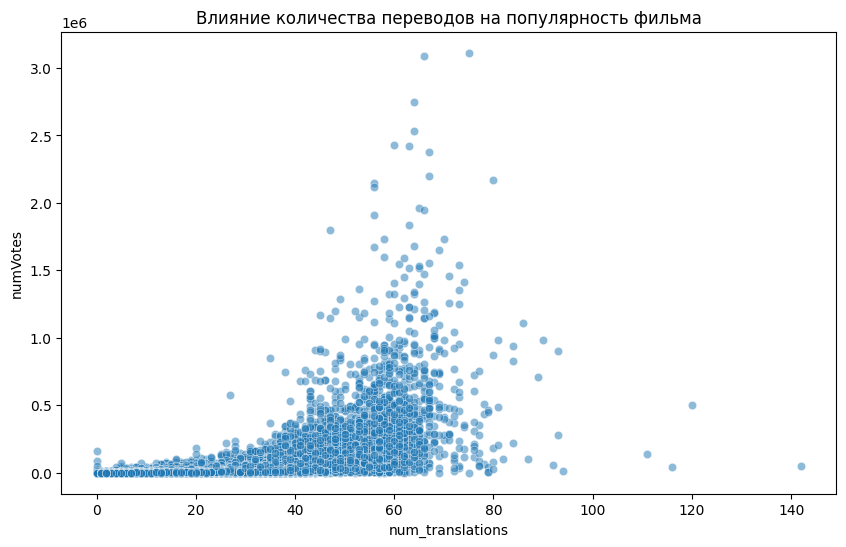

In [46]:
# Связь количества переводов и количества голосов
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies_with_akas, x='num_translations', y='numVotes', alpha=0.5)
plt.title('Влияние количества переводов на популярность фильма')
plt.show()

num_translations ~60 → пик голосов

Это подтверждает: популярность ведет к локализации

Но после 60 спад — может быть шум или очень нишевые фильмы

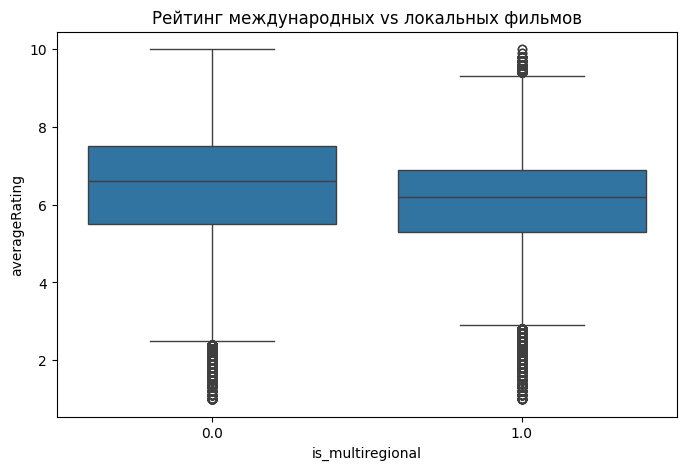

In [47]:
# Сравнение рейтингов
plt.figure(figsize=(8, 5))
sns.boxplot(data=movies_with_akas, x='is_multiregional', y='averageRating')
plt.title('Рейтинг международных vs локальных фильмов')
plt.show()

Логично! Мейнстрим vs артхаус — массовое кино редко получает высшие оценки

Меньший разброс ящика = более предсказуемое качество

In [48]:
# 10 самых "качественных" регионов
top_regions = movies_with_akas.groupby('main_region')['averageRating']\
    .mean().sort_values(ascending=False).head(10)
print(top_regions)

main_region
BI    8.800000
GI    8.600000
ZM    8.500000
IM    8.500000
DM    8.400000
MC    8.050000
MA    7.950000
MH    7.933333
TZ    7.876923
NI    7.860000
Name: averageRating, dtype: float64


Это малые страны (Бурунди, Гибралтар, Замбия)

Высокий рейтинг может быть из-за малой выборки

Нужно проверить количество фильмов по регионам

In [49]:
# Количество фильмов в топ-регионах
region_counts = movies_with_akas['main_region'].value_counts()
print(region_counts[['BI', 'GI', 'ZM', 'IM', 'DM']])

main_region
BI    1
GI    1
ZM    1
IM    2
DM    1
Name: count, dtype: int64


их рейтинги нестатистически значимы.

main_region
Unknown    43459
GB         40057
CA         37880
US         37074
AU         30866
BR         21958
DE         20361
IN         16296
ES         12664
FR         12218
Name: count, dtype: int64


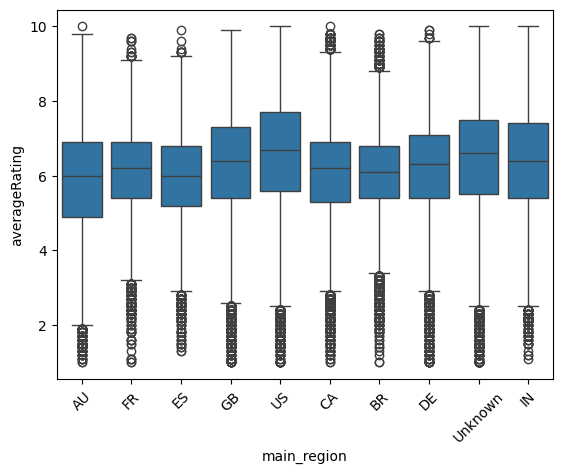

In [50]:
# Топ-10 регионов по количеству фильмов (не по рейтингу)
main_regions = movies_with_akas['main_region'].value_counts().head(10)
print(main_regions)

# Их средние рейтинги
regions_ratings = movies_with_akas[movies_with_akas['main_region'].isin(main_regions.index)]
sns.boxplot(data=regions_ratings, x='main_region', y='averageRating')
plt.xticks(rotation=45)
plt.show()

In [51]:
# Создаем копию чтобы не портить исходные данные
genres_analysis = movies_with_akas.copy()

# Разбиваем жанры на отдельные строки
genres_split = genres_analysis['genres'].str.split(',').explode()

# Создаем таблицу "фильм-жанр-страна"
genres_by_region = genres_analysis[['tconst', 'main_region']].join(genres_split)

# Топ-5 жанров по основным регионам
top_regions = ['US', 'GB', 'CA', 'DE', 'FR', 'IN']
for region in top_regions:
    region_genres = genres_by_region[genres_by_region['main_region'] == region]['genres'].value_counts().head(5)
    print(f"\n{region} топ жанры:")
    print(region_genres)


US топ жанры:
genres
Drama          11472
Documentary    11451
Comedy          8450
Horror          3126
Thriller        2466
Name: count, dtype: int64

GB топ жанры:
genres
Drama          16480
Documentary    10954
Comedy          8742
Romance         3394
Horror          3251
Name: count, dtype: int64

CA топ жанры:
genres
Drama       19209
Comedy      10308
Thriller     5458
Action       5397
Horror       5233
Name: count, dtype: int64

DE топ жанры:
genres
Drama          8020
Documentary    5787
Comedy         4827
Romance        1858
Crime          1558
Name: count, dtype: int64

FR топ жанры:
genres
Drama          5234
Documentary    3126
Comedy         3012
Romance         946
Crime           847
Name: count, dtype: int64

IN топ жанры:
genres
Drama       9338
Comedy      3847
Action      3567
Romance     3018
Thriller    2579
Name: count, dtype: int64


Drama — универсальный лидер во всех странах

Documentary сильно популярен в US, GB, DE, FR — западная культура

IN (Индия) — нет Documentary в топ-5, зато есть Action, Romance (Болливуд!)

CA (Канада) — больше Thriller, Action, Horror (близость к US)

DE, FR — европейское кино: Romance, Crime

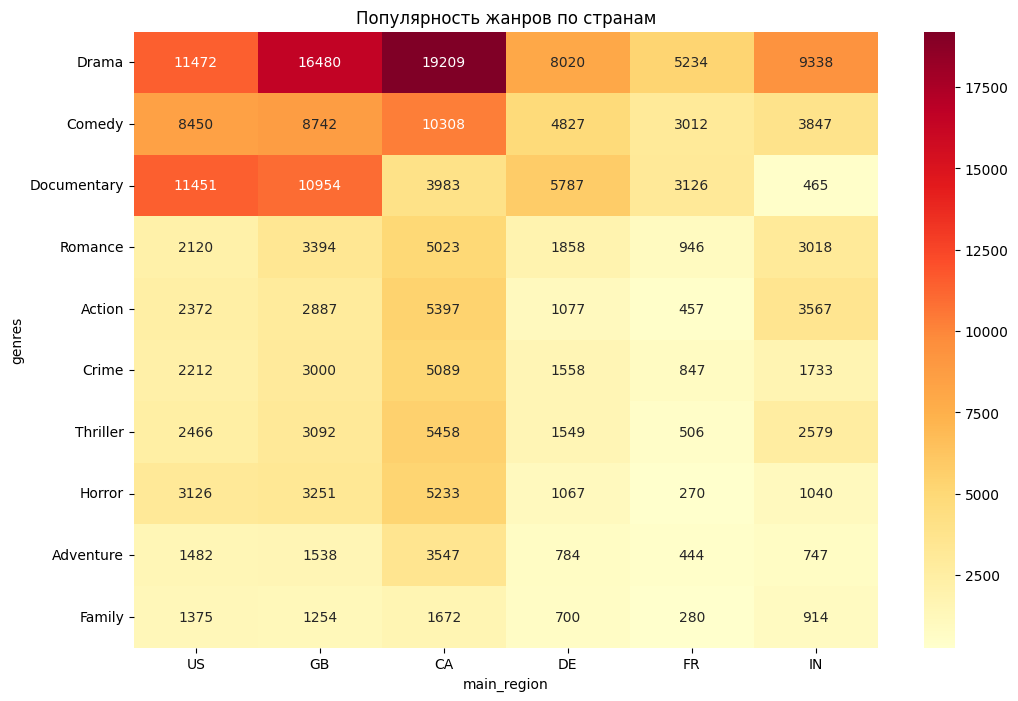

In [52]:
# Создаем тепловую карту популярности жанров по странам
genre_region_matrix = pd.crosstab(genres_by_region['genres'], genres_by_region['main_region'])

# Берем топ-10 жанров и топ-6 регионов
top_genres = genre_region_matrix.sum(axis=1).nlargest(10).index
top_regions = ['US', 'GB', 'CA', 'DE', 'FR', 'IN']

plt.figure(figsize=(12, 8))
sns.heatmap(genre_region_matrix.loc[top_genres, top_regions],
            annot=True, fmt='d', cmap='YlOrRd')
plt.title('Популярность жанров по странам')
plt.show()

НА БУДУЩЕЕ:
Как может быть полезен регион?

Cold start решение: Новый пользователь из DE → начинаем с немецких Drama/Crime
Пользователь из US смотрит IN кино → рекомендуем больше Болливуда

# Выводы по результатам EDA для RecSys

На основе проведенного разведочного анализа данных (EDA) были выявлены следующие важные инсайты, которые могут быть полезны при построении рекомендательной системы:

**1. Анализ Жанров и Времени:**

*   **Стабильно популярные жанры:** "Drama", "Documentary", "Comedy" остаются лидерами на протяжении долгого времени, что говорит об их универсальной привлекательности.
*   **Эволюция жанров:** Наблюдается значительный рост популярности жанров "Thriller" и "Action" в последние десятилетия, особенно после 2000 года. Это указывает на изменение предпочтений аудитории и важность учета современных трендов. Биографический жанр также демонстрирует сильный рост.
*   **Выводы для RecSys:**
    *   Учитывать популярность жанров как общую, так и в динамике по десятилетиям.
    *   Особое внимание уделить "триллерам" и "боевикам" для рекомендаций современной аудитории.(лидеры второго эшелона)
    *   Рассмотреть биографический жанр как растущую нишу.
    *   Использовать жанры как важные категориальные признаки.

**2. Анализ Рейтингов и Популярности:**

*   **Распределение рейтингов:** Рейтинги имеют нормальное распределение, но есть выбросы.
*   **Распределение голосов:** Количество голосов сильно скошено в сторону малых значений, что логично для большого датасета. Логарифмическая шкала помогает лучше увидеть распределение.
*   **Взаимосвязь рейтинга и популярности:** Есть положительная корреляция между количеством голосов и средним рейтингом, но она нелинейна. Фильмы с большим количеством голосов, как правило, имеют более "стабильный" рейтинг.
*   **Взаимосвязь рейтинга и количества голосов:** Рейтинг становится более стабильным при количестве голосов свыше 100.
*   **Жанры vs Рейтинг:** Жанры "News" и "Documentary" имеют самые высокие средние рейтинги, но низкое количество голосов. Жанры "Drama", "Comedy", "Action" имеют более низкие средние рейтинги, но огромное количество голосов (важно для взвешенного рейтинга).
*   **Взвешенный рейтинг:** Расчет взвешенного рейтинга показал, что наиболее "качественные" жанры по совокупности рейтинга и популярности - "Drama", "Comedy", "Action", "Thriller", "Adventure".
*   **Выводы для RecSys:**
    *   Использовать как сам рейтинг (`averageRating`), так и количество голосов (`numVotes`) как численные признаки.
    *   **Рассмотреть возможность использования взвешенного рейтинга** для более точной оценки качества фильмов.
    *   При фильтрации фильмов для рекомендаций можно установить порог по количеству голосов (например, > 100) для исключения фильмов с нестабильными рейтингами.
    *   **Год выпуска** может быть менее важен как признак качества, но важен для учета **актуальности** и трендов.

**3. Анализ Команды (Crew):**

*   **Продуктивность:** Выявлены самые продуктивные режиссеры и сценаристы.
*   **"Постоянные пары":** Существуют устойчивые пары режиссер-сценарист, что может говорить о сработанности команды.
*   **Режиссер-сценарист:** Фильмы, где режиссер сам является сценаристом, имеют немного более высокий средний рейтинг.
*   **Количество режиссеров/сценаристов:** Большое количество режиссеров или сценаристов не обязательно коррелирует с более высоким рейтингом. Выбросы в количестве сценаристов и режиссеров были усечены.
*   **knownForTitles - ИЗВЕСТНОСТЬ:** Этот признак может использоваться для оценки "звездности" или известности персоны.
*   **Ordering:** Порядок в списке `principals` важен, особенно для актеров, указывая на главные роли (обычно первые 10 позиций).
*   **Выводы для RecSys:**
    *   Использовать информацию о режиссерах, сценаристах и главных актерах (`nconst`) как категориальные признаки или использовать эмбеддинги для них.
    *   Можно использовать метрики "звездности" (`star_power` на основе `knownForTitles`) и "важности роли" (`ordering`) для учета веса персоны в фильме.
    *   Информация о постоянных командах может быть интересной фичей.
    *   Учитывать количество режиссеров и сценаристов как численные признаки.

**4. Анализ AKAS (Альтернативные названия):** Данный датасет был преобразован для облегчения памяти, удалены слабополезные колонки и преобразованы в новые:

*   **num_translations:** Количество альтернативных названий коррелирует с популярностью фильма (больше переводов у более популярных фильмов). Пик популярности наблюдается у фильмов с ~60 переводами.
*   **is_multiregional:** Международные фильмы имеют немного более низкий средний рейтинг, но меньший разброс по рейтингам, что может указывать на более предсказуемое качество по сравнению с локальными фильмами.
*   **main_region:** Основной регион производства/показа может быть полезным признаком для учета **культурных предпочтений аудитории**. Топ-регионы по количеству фильмов - US, GB, CA, DE, FR, IN. Анализ жанров по этим регионам выявил интересные культурные различия (например, популярность Documentary на Западе и Action/Romance в Индии).
*   **Выводы для RecSys:**
    *   Использовать `num_translations` и `is_multiregional` как численные признаки.
    *   Использовать `main_region` как категориальный признак для учета региональных предпочтений.

**Потенциальные фичи для модели:**

*   **Численные:** `startYear` / `decade`, `runtimeMinutes`, `averageRating`, `numVotes`, `num_translations`, `is_multiregional`, `num_directors`, `num_writers`, `ordering`, `star_power`.
*   **Категориальные:** `genres` (после OHE), `decade`, `main_region`, `category` (роль персоны), `nconst` (идентификаторы персон).
*   **Комбинированные:** Взаимодействия признаков (например, жанр * регион, режиссер * жанр).
